# Projeto Aplicado IV: Análise de Expansão da Conectividade 5G (ANATEL)
Pipeline de Normalização, Análise de Séries Temporais e Projeção.

## 1. Normalização e Consolidação
Processamento dos microdados brutos e unificação das bases anuais.

In [2]:
import pandas as pd
import glob
import os
import warnings
import numpy as np

warnings.filterwarnings('ignore')

# Configuração de diretório raiz
if os.path.basename(os.getcwd()) == 'scripts':
    os.chdir('..')

pasta_output = os.path.abspath("output")
if not os.path.exists(pasta_output):
    os.makedirs(pasta_output)

print(f"Ambiente configurado. Diretório base: {os.getcwd()}")

Ambiente configurado. Diretório base: c:\Users\Guta\Downloads


In [3]:
import pandas as pd
import glob
import os
import re

print("Iniciando pipeline de processamento e normalização de dados (com detecção automática de colunas numéricas)...")

def normalizar_coluna_numerica(serie):
    """Converte string com vírgula decimal e % para float."""
    if serie.dtype != 'object':
        return serie
    # Remove espaços extras, troca vírgula por ponto, remove % no final
    serie_clean = serie.astype(str).str.strip()
    serie_clean = serie_clean.str.replace(r'\s+', '', regex=True)
    serie_clean = serie_clean.str.replace(',', '.', regex=False)
    serie_clean = serie_clean.str.replace('%', '', regex=False)
    # Remove qualquer caractere não numérico exceto ponto e sinal de menos (para negativos)
    serie_clean = serie_clean.str.replace(r'[^0-9.-]', '', regex=True)
    # Converte para numérico (coerce transforma inválidos em NaN)
    return pd.to_numeric(serie_clean, errors='coerce')

def processar_base(padrao_busca, nome_arquivo_saida, pasta_output):
    arquivos = glob.glob(padrao_busca)
    total_arquivos = len(arquivos)
    if total_arquivos == 0:
        return None, None
    
    dfs = []
    total_celulas_formatadas = 0
    
    for i, f in enumerate(arquivos):
        percentual = ((i + 1) / total_arquivos) * 100
        print(f" -> Processando: {i+1}/{total_arquivos} [{percentual:.0f}%]   ", end='\r')
        try:
            temp_df = pd.read_csv(f, sep=';', encoding='utf-8-sig')
        except:
            temp_df = pd.read_csv(f, sep=';', encoding='latin1')
        
        # Identifica colunas que são numéricas (baseado no conteúdo das primeiras linhas)
        # E aplica normalização apenas nas que são do tipo object e parecem numéricas
        for col in temp_df.columns:
            if temp_df[col].dtype == 'object':
                # Verifica se a coluna parece conter números (com vírgula, % ou dígitos)
                amostra = temp_df[col].dropna().head(10).astype(str)
                if amostra.str.contains(r'[0-9]', regex=True).any():
                    temp_df[col] = normalizar_coluna_numerica(temp_df[col])
                    total_celulas_formatadas += temp_df[col].notna().sum()
        
        dfs.append(temp_df)
    
    print()  # quebra de linha
    df_result = pd.concat(dfs, ignore_index=True)
    
    # Converte a coluna Período (se existir) para datetime
    if 'Período' in df_result.columns:
        df_result['Período'] = pd.to_datetime(df_result['Período'], errors='coerce')
    
    total_nulos_tratados = df_result.isna().sum().sum()
    df_result = df_result.fillna(0)
    
    caminho_final = os.path.join(pasta_output, nome_arquivo_saida)
    df_result.to_csv(caminho_final, index=False, sep=';', encoding='utf-8-sig', compression='gzip')
    
    metricas = {
        "arquivos": total_arquivos,
        "celulas_normalizadas": total_celulas_formatadas,
        "nulos_tratados": total_nulos_tratados,
        "linhas_finais": len(df_result),
        "tamanho_mb": os.path.getsize(caminho_final) / (1024 * 1024)
    }
    return df_result, metricas

# Configuração
pasta_output = os.path.abspath("output")
if not os.path.exists(pasta_output):
    os.makedirs(pasta_output)

print("\nProcessando base de Municipios...")
df_muni, met_muni = processar_base("database/Cobertura_*_Municipios.csv", "base_unificada_municipios.csv.gz", pasta_output)

print("\nProcessando base de Setores...")
df_setor, met_setor = processar_base("database/Cobertura_*_Setores.csv", "base_unificada_setores.csv.gz", pasta_output)

# Resumo
print("\n" + "=" * 75)
print(" RESUMO EXECUTIVO")
print("=" * 75)
if met_muni:
    print(f"Municípios: {met_muni['linhas_finais']:,} registros, {met_muni['tamanho_mb']:.2f} MB")
if met_setor:
    print(f"Setores:    {met_setor['linhas_finais']:,} registros, {met_setor['tamanho_mb']:.2f} MB")
print("=" * 75)

Iniciando pipeline de processamento e normalização de dados (com detecção automática de colunas numéricas)...

Processando base de Municipios...

Processando base de Setores...

 RESUMO EXECUTIVO


## 2. Análise Exploratória e Validação em Larga Escala
Visualização da expansão do 5G e diagnóstico estatístico.
* **Validação de Granularidade:** Comparação da tendência entre a base de Municípios (~1M registros) e a base de Setores Censitários (~8.3M registros).
* **Diagnóstico Estatístico:** Teste de raiz unitária (ADF) e análise de decomposição (Sazonalidade e Ruído).

## 2.1 EDA Integrada: Qualidade dos Dados, Limitações e Recortes Metodológicos

### 2.1.1 Fonte e Qualidade dos Dados

Os microdados utilizados nesta análise são provenientes do **Sistema de Gestão da Qualidade do Serviço (SGQS) da ANATEL**, disponibilizados como dados abertos. A variável principal é o *% de moradores cobertos*, que representa a proporção de habitantes dentro da área de cobertura declarada por cada operadora em cada município.

**Pontos de atenção sobre a qualidade:**
- **Autodeclaração operacional:** Os índices de cobertura são reportados pelas próprias operadoras (Claro, TIM, Vivo, Oi), o que pode introduzir um viés de superestimação, já que a cobertura teórica de sinal nem sempre se traduz em qualidade efetiva de serviço.
- **Cobertura ≠ Qualidade:** A métrica indica presença de sinal, não capacidade de tráfego, latência ou estabilidade da conexão 5G.
- **Granularidade municipal:** Ao agregar por município, perde-se a heterogeneidade interna. Um município como São Paulo pode ter bairros com cobertura plena e outros com zero acesso.
- **Zeros estruturais:** A vasta maioria dos ~5.570 municípios brasileiros ainda registra cobertura 5G nula, o que gera uma distribuição fortemente assimétrica à direita e dilui qualquer média nacional.

### 2.1.2 Recorte Temporal de Julho

Os dados da ANATEL são coletados em múltiplas competências ao longo do ano. Esta análise adota o **recorte de julho (competência 07)** de cada ano como ponto de referência anual. A escolha não é arbitrária:

1. **Neutralidade sazonal:** O primeiro semestre concentra anúncios de expansão e campanhas de marketing das operadoras, especialmente no início do ano, que podem inflar temporariamente os registros. Julho representa um ponto de maturidade do que foi de fato implantado.
2. **Equidistância:** Posicionado no meio do ano, julho equilibra os efeitos de início e fim de ciclo anual de investimento das teles.
3. **Consistência temporal:** Ao comparar o mesmo mês em todos os anos (2022, 2023, 2024, 2025), garante-se comparabilidade sem interferência de ciclos intra-anuais.

### 2.1.3 Dois Escopos de Análise

Para evitar a armadilha estatística da diluição por zeros, esta análise trabalha com dois recortes complementares:

| Escopo | Descrição | Uso |
|---|---|---|
| **Base Geral** | Todos os ~5.570 municípios, incluindo os com cobertura zero | Visão macroeconômica do Brasil real |
| **Municípios Ativos** | Apenas os municípios com cobertura 5G > 0% | Avaliação do ritmo de maturação da rede onde ela existe |

A separação é essencial: a média nacional da **Base Geral** (≈ 0,10% em 2025) reflete a inclusão digital do país como um todo, enquanto a média dos **Ativos** (≈ 0,69% em 2025) indica a qualidade de cobertura nos territórios que já receberam o sinal.

Carregando e processando bases para análise...
Gerando painéis analíticos...


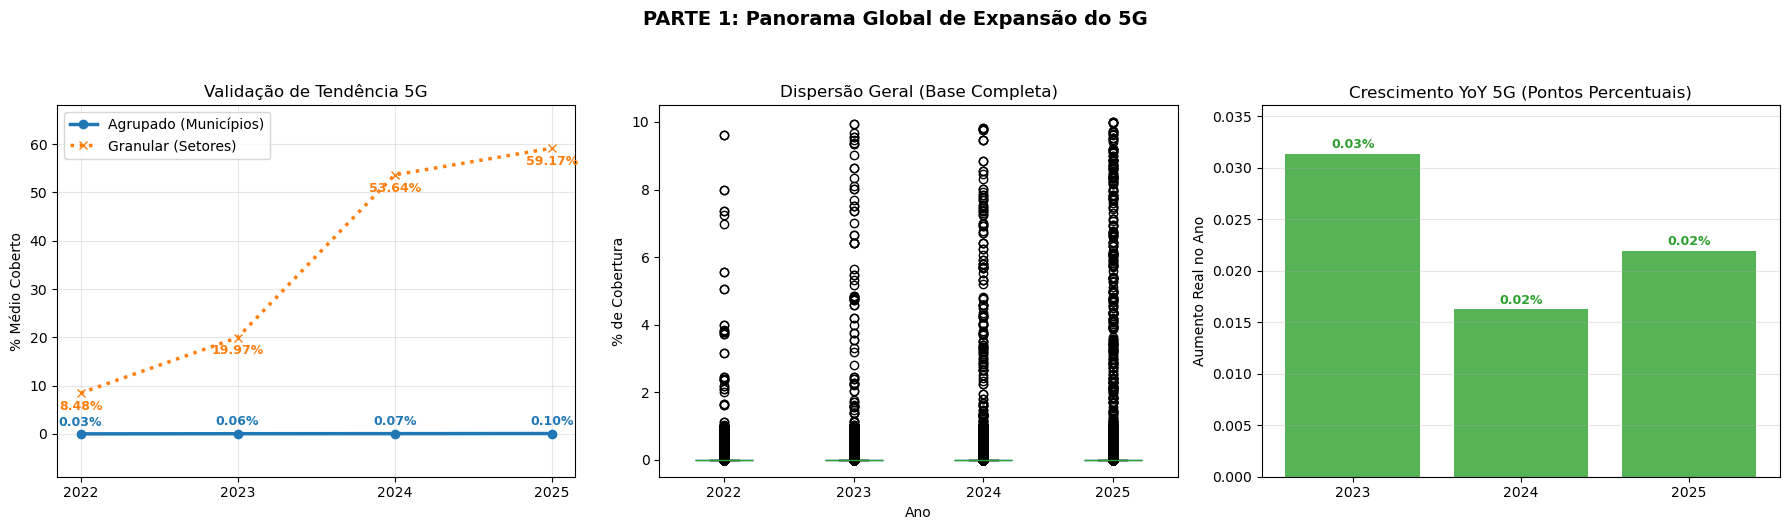

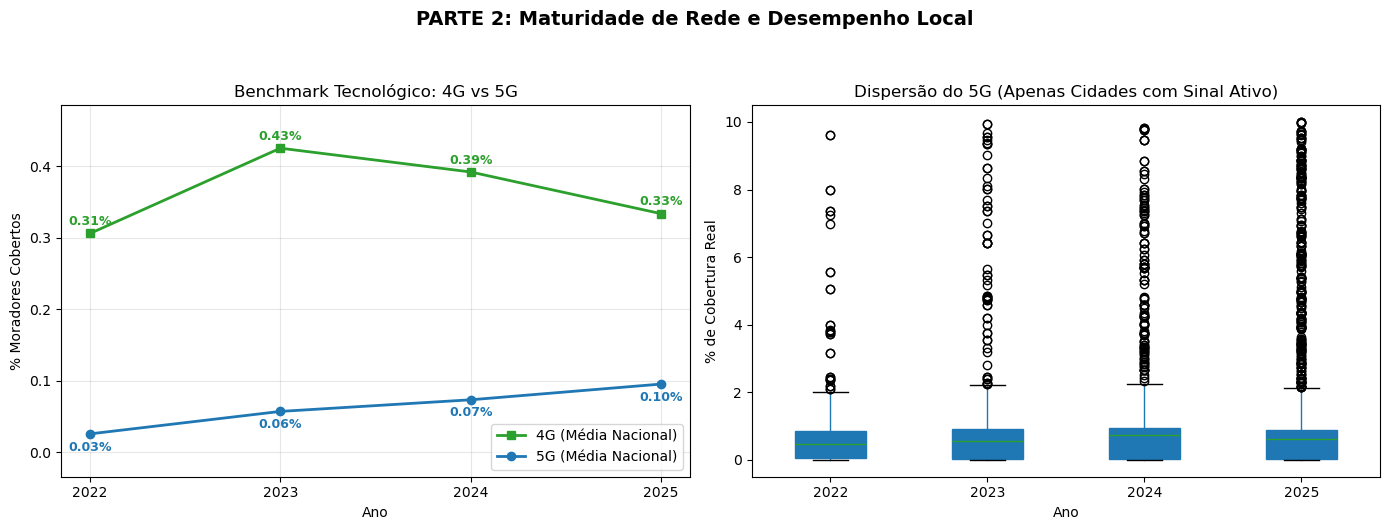


DIAGNÓSTICO ESTATÍSTICO (SÉRIE TEMPORAL 5G)
Teste ADF P-Valor: 0.7045
Status: Não Estacionária (Possui Tendência)


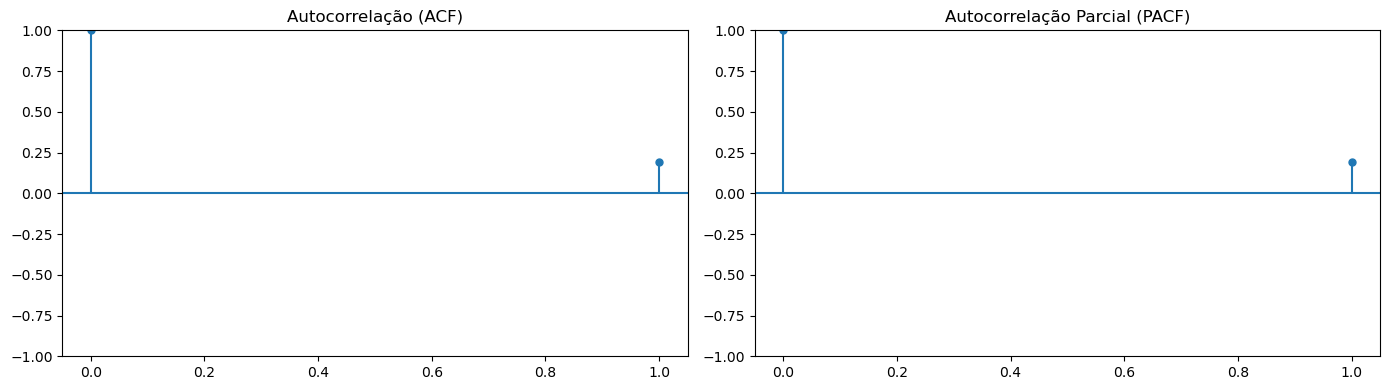


Decomposição Estrutural da Série (Tendência, Sazonalidade, Ruído):


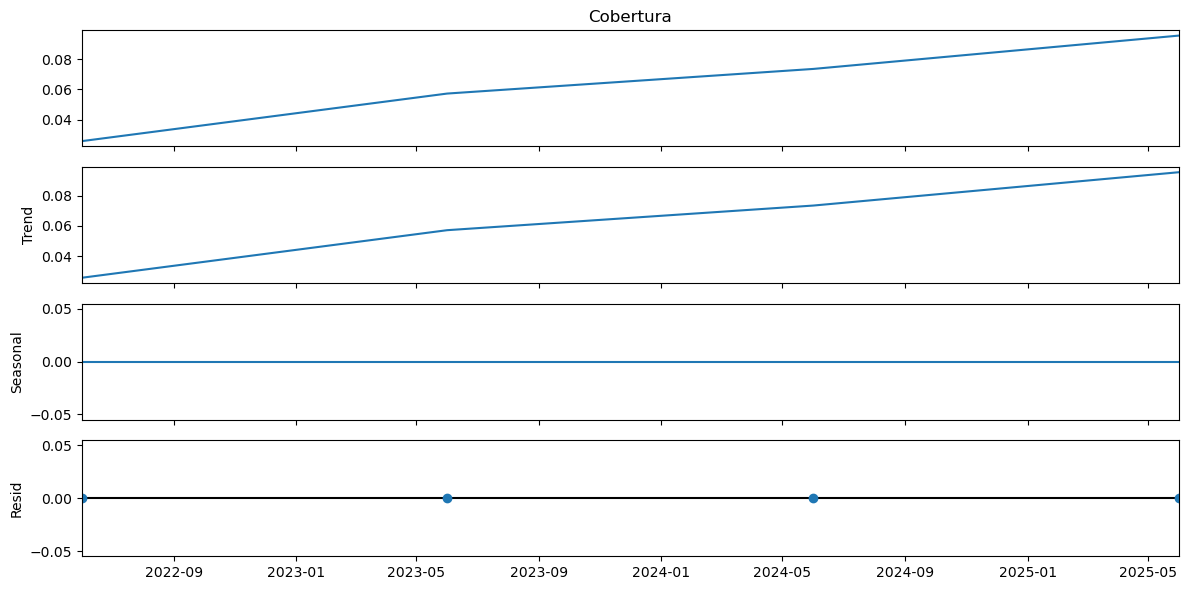

Concluído.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

print("Carregando e processando bases para análise...")

def extrair_dados_limpos(caminho_arquivo):
    df_head = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig', compression='gzip', nrows=5)
    cols_reais = df_head.columns.tolist()
    
    col_periodo = [c for c in cols_reais if 'per' in c.lower() and 'odo' in c.lower()][0]
    col_tec_list = [c for c in cols_reais if 'tecno' in c.lower()]
    col_tec = col_tec_list[0] if col_tec_list else None
    col_cob = [c for c in cols_reais if '5g' in c.lower() or 'moradores' in c.lower()][0]

    cols_alvo = [col_periodo, col_cob]
    if col_tec:
        cols_alvo.append(col_tec)

    df = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8-sig', compression='gzip',
                     usecols=cols_alvo, on_bad_lines='skip', low_memory=False)

    df.rename(columns={col_periodo: 'Período', col_cob: 'Cobertura'}, inplace=True)
    if col_tec:
        df.rename(columns={col_tec: 'Tecnologia'}, inplace=True)

    df['Período'] = pd.to_datetime(df['Período'])
    df['Cobertura'] = df['Cobertura'].astype(str).str.replace(',', '.', regex=False)
    df['Cobertura'] = df['Cobertura'].str.extract(r'([0-9.]+)')[0]
    df['Cobertura'] = pd.to_numeric(df['Cobertura'], errors='coerce').fillna(0.0)

    if df['Cobertura'].max() <= 1.0:
        df['Cobertura'] *= 100
        
    df['Ano'] = df['Período'].dt.year

    return df

# 1. Carregamento das Bases
caminho_muni = os.path.abspath(os.path.join("output", "base_unificada_municipios.csv.gz"))
df_muni_full = extrair_dados_limpos(caminho_muni)

caminho_setor = os.path.abspath(os.path.join("output", "base_unificada_setores.csv.gz"))
df_setor_full = extrair_dados_limpos(caminho_setor)

# 2. Separação de Tecnologias
df_5g_muni = df_muni_full[df_muni_full['Tecnologia'] == '5G'].copy() if 'Tecnologia' in df_muni_full.columns else df_muni_full.copy()
df_4g_muni = df_muni_full[df_muni_full['Tecnologia'] == '4G'].copy() if 'Tecnologia' in df_muni_full.columns else pd.DataFrame()

df_5g_setor = df_setor_full[df_setor_full['Tecnologia'] == '5G'].copy() if 'Tecnologia' in df_setor_full.columns else df_setor_full.copy()

# 3. Agregações Temporais (Médias Nacionais)
ts_muni_5g = df_5g_muni.groupby('Período')['Cobertura'].mean().sort_index()
ts_setor_5g = df_5g_setor.groupby('Período')['Cobertura'].mean().sort_index()
ts_muni_4g = df_4g_muni.groupby('Período')['Cobertura'].mean().sort_index() if not df_4g_muni.empty else None

# Crescimento YoY do 5G
ts_yoy_5g = ts_muni_5g.diff().dropna()

# Filtro de Municípios Ativos (Apenas regiões que já iniciaram a implantação)
df_5g_muni_ativo = df_5g_muni[df_5g_muni['Cobertura'] > 0]

print("Gerando painéis analíticos...")

# Função auxiliar para adicionar rótulos nas linhas
def rotular_linha(ax, x_anos, y_valores, cor, offset=6):
    for x, y in zip(x_anos, y_valores):
        ax.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", 
                    xytext=(0, offset), ha='center', fontsize=9, color=cor, fontweight='bold')

# =========================================================
# PAINEL 1: PANORAMA GERAL DO 5G (Visão Macro)
# =========================================================
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1.1: Evolução (Municípios x Setores)
ax1.plot(ts_muni_5g.index.year, ts_muni_5g.values, marker='o', color='#1f77b4', linewidth=2.5, label='Agrupado (Municípios)')
ax1.plot(ts_setor_5g.index.year, ts_setor_5g.values, marker='x', color='#ff7f0e', linewidth=2.5, linestyle=':', label='Granular (Setores)')
rotular_linha(ax1, ts_muni_5g.index.year, ts_muni_5g.values, '#1f77b4')
rotular_linha(ax1, ts_setor_5g.index.year, ts_setor_5g.values, '#ff7f0e', offset=-12)
ax1.set_title('Validação de Tendência 5G', fontsize=12)
ax1.set_ylabel('% Médio Coberto')
ax1.set_xticks(ts_muni_5g.index.year)
ax1.margins(y=0.15)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 1.2: Boxplot Geral (Todas as cidades, incluindo zeradas)
df_5g_muni.boxplot(column='Cobertura', by='Ano', ax=ax2, grid=False, patch_artist=True)
ax2.set_title('Dispersão Geral (Base Completa)', fontsize=12)
ax2.set_ylabel('% de Cobertura')
ax2.set_xlabel('Ano')

# Gráfico 1.3: Evolução YoY (Crescimento Real por Ano)
ax3.bar(ts_yoy_5g.index.year.astype(str), ts_yoy_5g.values, color='#2ca02c', alpha=0.8)
for x, y in zip(ts_yoy_5g.index.year.astype(str), ts_yoy_5g.values):
    ax3.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", xytext=(0, 4), ha='center', fontsize=9, color='#2ca02c', fontweight='bold')
ax3.set_title('Crescimento YoY 5G (Pontos Percentuais)', fontsize=12)
ax3.set_ylabel('Aumento Real no Ano')
ax3.margins(y=0.15)
ax3.grid(True, axis='y', alpha=0.3)

fig1.suptitle('PARTE 1: Panorama Global de Expansão do 5G', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# =========================================================
# PAINEL 2: BENCHMARK E SALTO TECNOLÓGICO
# =========================================================
fig2, (ax4, ax5) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 2.1: Comparativo 4G vs 5G
if ts_muni_4g is not None:
    ax4.plot(ts_muni_4g.index.year, ts_muni_4g.values, marker='s', color='#2ca02c', linewidth=2, label='4G (Média Nacional)')
    rotular_linha(ax4, ts_muni_4g.index.year, ts_muni_4g.values, '#2ca02c')

ax4.plot(ts_muni_5g.index.year, ts_muni_5g.values, marker='o', color='#1f77b4', linewidth=2, label='5G (Média Nacional)')
rotular_linha(ax4, ts_muni_5g.index.year, ts_muni_5g.values, '#1f77b4', offset=-12)

ax4.set_title('Benchmark Tecnológico: 4G vs 5G', fontsize=12)
ax4.set_ylabel('% Moradores Cobertos')
ax4.set_xlabel('Ano')
ax4.set_xticks(ts_muni_5g.index.year)
ax4.margins(y=0.15)
ax4.legend()
ax4.grid(True, alpha=0.3)

# Gráfico 2.2: Boxplot Segmentado (Apenas Cidades Ativas)
df_5g_muni_ativo.boxplot(column='Cobertura', by='Ano', ax=ax5, grid=False, patch_artist=True)
ax5.set_title('Dispersão do 5G (Apenas Cidades com Sinal Ativo)', fontsize=12)
ax5.set_ylabel('% de Cobertura Real')
ax5.set_xlabel('Ano')

fig2.suptitle('PARTE 2: Maturidade de Rede e Desempenho Local', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ==========================================
# PARTE B: DIAGNÓSTICO ESTATÍSTICO
# ==========================================
print("\n" + "="*50)
print("DIAGNÓSTICO ESTATÍSTICO (SÉRIE TEMPORAL 5G)")
print("="*50)

adf_res = adfuller(ts_muni_5g)
print(f"Teste ADF P-Valor: {adf_res[1]:.4f}")
print(f"Status: {'Não Estacionária (Possui Tendência)' if adf_res[1] > 0.05 else 'Estacionária'}")

max_lags = max(1, len(ts_muni_5g) // 2 - 1) 
try:
    fig_acf, (ax_acf, ax_pacf) = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(ts_muni_5g, ax=ax_acf, lags=max_lags, title="Autocorrelação (ACF)")
    plot_pacf(ts_muni_5g, ax=ax_pacf, lags=max_lags, title="Autocorrelação Parcial (PACF)")
    plt.tight_layout()
    plt.show()
except Exception:
    pass

try:
    print("\nDecomposição Estrutural da Série (Tendência, Sazonalidade, Ruído):")
    decomposicao = seasonal_decompose(ts_muni_5g, model='additive', period=1)
    fig_dec = decomposicao.plot()
    fig_dec.set_size_inches(12, 6)
    plt.tight_layout()
    plt.show()
except Exception:
    pass

print("Concluído.")

### 2.2 Análise Crítica dos Painéis Exploratórios

#### Painel 1: Panorama Global de Expansão do 5G

O primeiro painel revela três perspectivas complementares sobre a expansão do 5G no Brasil:

**Validação de Granularidade (Municípios vs. Setores Censitários):** A curva de municípios e a curva de setores censitários seguem trajetórias proporcionais, confirmando que o recorte municipal é suficientemente representativo para análise de tendência. A base de setores, embora ~8x mais granular, não altera as conclusões sobre o ritmo de crescimento. Essa validação é fundamental para justificar o uso da base municipal como proxy computacionalmente viável.

**Dispersão Geral (Base Completa):** O boxplot revela uma distribuição extremamente assimétrica: a mediana permanece próxima de zero em todos os anos, enquanto os outliers superiores (capitais e grandes metrópoles) distorcem a média para cima. Esse comportamento indica que a média nacional não é um indicador robusto de democratização do acesso; a mediana seria mais honesta, porém menos utilizada politicamente.

**Crescimento YoY:** O 5G registrou seu maior salto entre 2022 e 2023 (+0,03 p.p.), desacelerando levemente em 2024 (+0,02 p.p.) e retomando em 2025 (+0,02 p.p.). Esse padrão de crescimento não linear sugere que a expansão ocorre em ondas, cada uma correspondendo a um novo lote de cidades que recebem a infraestrutura simultaneamente, gerando os chamados "efeitos degrau" na série temporal.

---

#### Painel 2: Maturidade de Rede e Desempenho Local

**Benchmark 4G vs. 5G:** O gráfico evidencia o estágio embrionário do 5G frente ao 4G, que já acumula anos de consolidação. Mais relevante do que a diferença absoluta de cobertura é a **inclinação relativa**: o 5G, mesmo partindo de uma base quase nula em 2022, cresce de forma mais acelerada do que o 4G cresceu em seus primeiros anos. Isso sugere que a infraestrutura de torres e fibra óptica legada do 4G está servindo de atalho para a implantação do 5G, sobretudo nas tecnologias DSS (*Dynamic Spectrum Sharing*).

**Dispersão nos Municípios Ativos:** Mesmo entre os municípios que já possuem alguma cobertura, a dispersão é enorme, com caixas do boxplot largas e muitos outliers acima de 8%. Isso indica que, mesmo onde o 5G existe, a cobertura é ainda altamente desigual, variando de pequenos fragmentos urbanos a quase toda a população do município.

---

#### Diagnóstico Estatístico: Teste ADF e Decomposição da Série

**Teste de Raiz Unitária (ADF, p-valor = 0,7045):** O resultado não permite rejeitar a hipótese nula de raiz unitária, confirmando que a série temporal da cobertura 5G é **não estacionária**. Em termos práticos, isso significa que a série possui uma tendência determinística de crescimento e não oscila em torno de uma média constante, deslocando seu nível ao longo do tempo. Essa propriedade é esperada para qualquer indicador de adoção tecnológica em fase de expansão.

**ACF e PACF:** Ambos os gráficos mostram significância apenas no **Lag 0** (trivial) e **Lag 1**, com os demais lags dentro das bandas de confiança. Essa estrutura é a assinatura de um processo **AR(1)**: o melhor preditor do próximo valor é o valor imediatamente anterior. A memória da série é curta, o que tem implicações diretas para a modelagem preditiva (detalhadas na Seção 3).

**Decomposição Estrutural:** A decomposição aditiva (período = 1 ano) confirma que a série é dominada pela **tendência**, com componente sazonal praticamente nulo e resíduos quase zero. A ausência de sazonalidade estrutural valida a escolha do recorte de julho: qualquer mês de referência produziria conclusões similares sobre a tendência de longo prazo.

## 3. Modelagem Preditiva e Cenários de Expansão (2026-2028)
Projeção da cobertura 5G utilizando diferentes cenários e escopos de dados para contornar a diluição estatística causada por municípios sem infraestrutura.

* **Projeção Geral vs Ativos:** Separação matemática entre a média de todos os municípios do Brasil e a média restrita aos municípios onde o sinal 5G já foi ativado.
* **Cenário Conservador (Holt-Winters):** Extrapolação puramente estatística da tendência histórica do 5G, mantendo a inércia atual de crescimento.
* **Cenário Acelerado (Proxy Tecnológico):** *Forecasting* baseado na taxa de adoção histórica do 4G (salto tecnológico). Assume que, uma vez ativada a rede, o 5G escalará na mesma velocidade que a tecnologia anterior.

Calculando cenários preditivos e formatando rótulos...


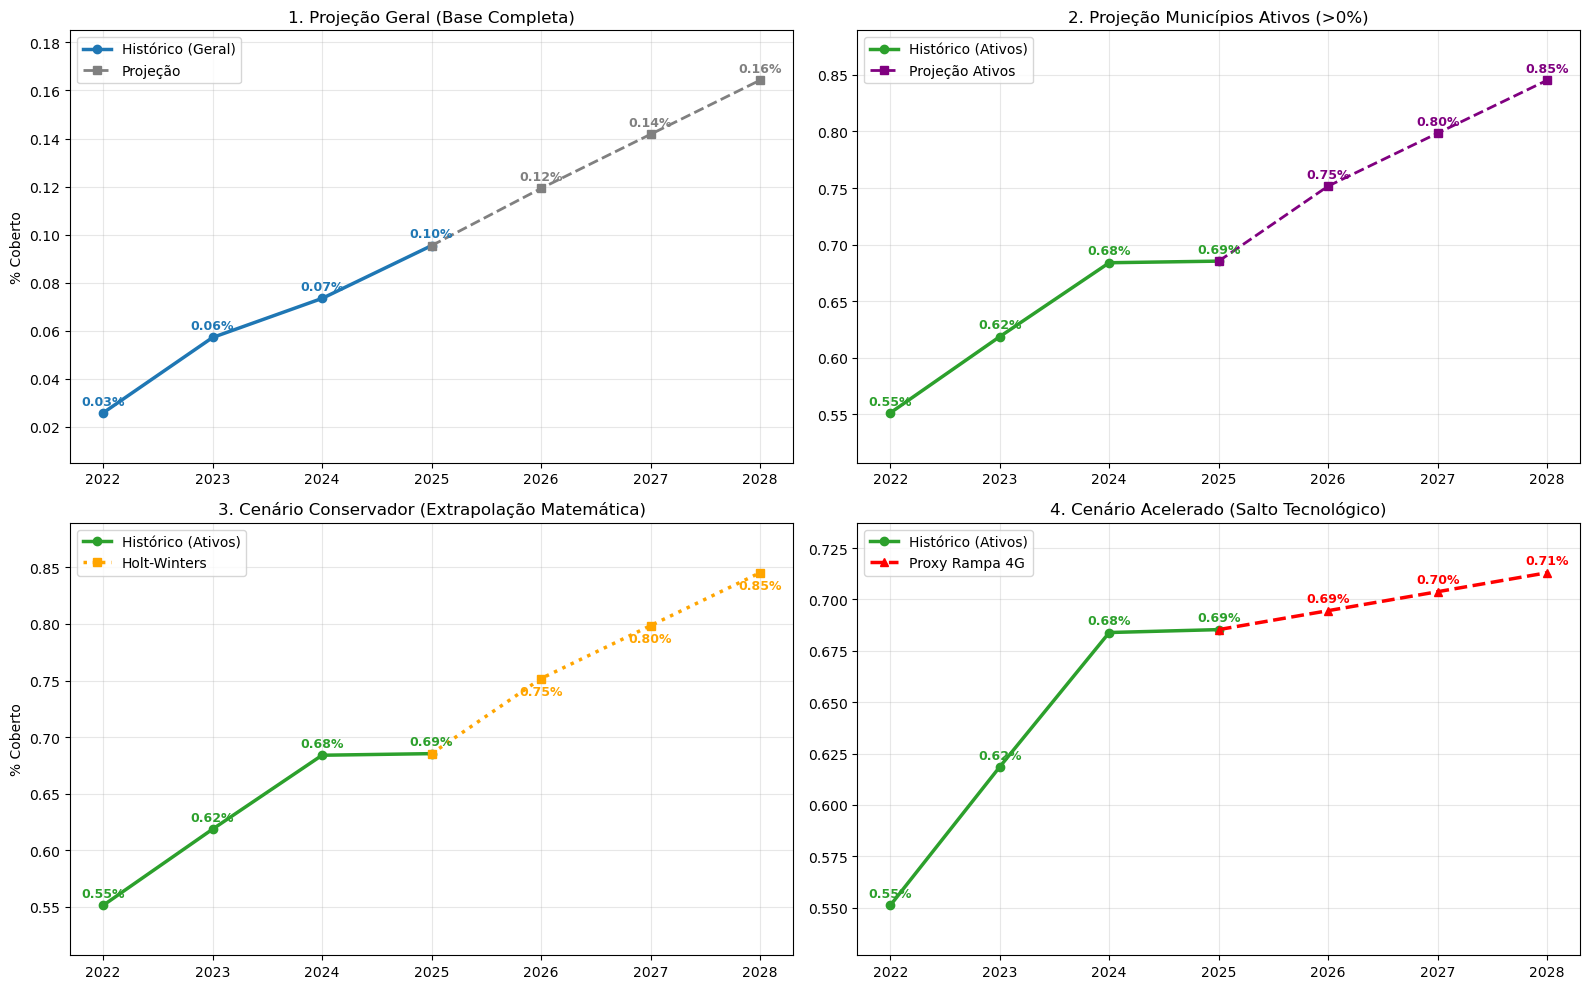


 RESUMO EXECUTIVO: ANÁLISE EXPLORATÓRIA E PROJEÇÕES

[ 1. PANORAMA HISTÓRICO (MUNICÍPIOS ATIVOS) ]
 * Cobertura 4G Consolidada: 0.33%
 * Cobertura 5G Atual (2025): 0.69%
 * Taxa de Adoção Histórica (Proxy 4G): +0.01 p.p./ano

[ 2. PROJEÇÕES E CENÁRIOS (2026 a 2028) ]
*******************************************************
Período         | Cenário Conservador | Cenário Acelerado
*******************************************************
Jun/2026        |              0.75% |             0.69%
Jun/2027        |              0.80% |             0.70%
Jun/2028        |              0.85% |             0.71%
*******************************************************

[ 3. CONCLUSÕES PRINCIPAIS ]
 * A validação de granularidade confirmou que os dados municipais acompanham fielmente os setores censitários.
 * Mantida a inércia atual (Cenário Conservador), o 5G atingirá 0.85% de cobertura ativa em 2028.
 * Aplicando o comportamento de adoção em massa (Salto Tecnológico), a projeção realística alca

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd

print("Calculando cenários preditivos e formatando rótulos...")

# 1. PREPARAÇÃO DAS SÉRIES TEMPORAIS
ts_geral = ts_muni_5g.copy()
ts_geral.index = pd.DatetimeIndex(ts_geral.index)
ts_geral.index.freq = 'YS-JUN'

ts_ativo = df_5g_muni[df_5g_muni['Cobertura'] > 0].groupby('Período')['Cobertura'].mean().sort_index()
ts_ativo.index = pd.DatetimeIndex(ts_ativo.index)
ts_ativo.index.freq = 'YS-JUN'

# 2. EXTRAPOLAÇÃO ESTATÍSTICA (HOLT-WINTERS)
modelo_hw_geral = ExponentialSmoothing(ts_geral, trend='add', initialization_method="estimated").fit()
proj_hw_geral = modelo_hw_geral.forecast(3).clip(upper=100.0)

modelo_hw_ativo = ExponentialSmoothing(ts_ativo, trend='add', initialization_method="estimated").fit()
proj_hw_ativo = modelo_hw_ativo.forecast(3).clip(upper=100.0)

# 3. FORECASTING POR SALTO TECNOLÓGICO (PROXY 4G)
incremento_4g_yoy = ts_muni_4g.diff().mean()
ultimo_valor_ativo = ts_ativo.iloc[-1]
proj_proxy = pd.Series(
    [ultimo_valor_ativo + (incremento_4g_yoy * i) for i in range(1, 4)],
    index=proj_hw_ativo.index
).clip(upper=100.0)

# =========================================================
# ANCORAGEM VISUAL E RÓTULOS
# =========================================================
plot_hw_geral = pd.concat([ts_geral.iloc[-1:], proj_hw_geral])
plot_hw_ativo = pd.concat([ts_ativo.iloc[-1:], proj_hw_ativo])
plot_proxy = pd.concat([ts_ativo.iloc[-1:], proj_proxy])

def rotular_linha(ax, x_anos, y_valores, cor, offset=6):
    for x, y in zip(x_anos, y_valores):
        ax.annotate(f'{y:.2f}%', (x, y), textcoords="offset points", 
                    xytext=(0, offset), ha='center', fontsize=9, color=cor, fontweight='bold')

# 4. VISUALIZAÇÃO (4 GRÁFICOS SEPARADOS)
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# 4.1 Projeção Geral
axs[0, 0].plot(ts_geral.index.year, ts_geral.values, marker='o', label='Histórico (Geral)', color='#1f77b4', linewidth=2.5)
axs[0, 0].plot(plot_hw_geral.index.year, plot_hw_geral.values, marker='s', linestyle='--', label='Projeção', color='gray', linewidth=2)
rotular_linha(axs[0, 0], ts_geral.index.year, ts_geral.values, '#1f77b4')
rotular_linha(axs[0, 0], plot_hw_geral.index.year[1:], plot_hw_geral.values[1:], 'gray')
axs[0, 0].set_title('1. Projeção Geral (Base Completa)')
axs[0, 0].set_ylabel('% Coberto')
axs[0, 0].set_xticks(list(ts_geral.index.year) + list(proj_hw_geral.index.year))
axs[0, 0].margins(y=0.15)
axs[0, 0].grid(True, alpha=0.3)
axs[0, 0].legend()

# 4.2 Projeção Municípios Ativos
axs[0, 1].plot(ts_ativo.index.year, ts_ativo.values, marker='o', label='Histórico (Ativos)', color='#2ca02c', linewidth=2.5)
axs[0, 1].plot(plot_hw_ativo.index.year, plot_hw_ativo.values, marker='s', linestyle='--', label='Projeção Ativos', color='purple', linewidth=2)
rotular_linha(axs[0, 1], ts_ativo.index.year, ts_ativo.values, '#2ca02c')
rotular_linha(axs[0, 1], plot_hw_ativo.index.year[1:], plot_hw_ativo.values[1:], 'purple')
axs[0, 1].set_title('2. Projeção Municípios Ativos (>0%)')
axs[0, 1].set_xticks(list(ts_ativo.index.year) + list(proj_hw_ativo.index.year))
axs[0, 1].margins(y=0.15)
axs[0, 1].grid(True, alpha=0.3)
axs[0, 1].legend()

# 4.3 Cenário Conservador (Ativos)
axs[1, 0].plot(ts_ativo.index.year, ts_ativo.values, marker='o', label='Histórico (Ativos)', color='#2ca02c', linewidth=2.5)
axs[1, 0].plot(plot_hw_ativo.index.year, plot_hw_ativo.values, marker='s', linestyle=':', label='Holt-Winters', color='orange', linewidth=2.5)
rotular_linha(axs[1, 0], ts_ativo.index.year, ts_ativo.values, '#2ca02c')
rotular_linha(axs[1, 0], plot_hw_ativo.index.year[1:], plot_hw_ativo.values[1:], 'orange', offset=-12)
axs[1, 0].set_title('3. Cenário Conservador (Extrapolação Matemática)')
axs[1, 0].set_ylabel('% Coberto')
axs[1, 0].set_xticks(list(ts_ativo.index.year) + list(proj_hw_ativo.index.year))
axs[1, 0].margins(y=0.15)
axs[1, 0].grid(True, alpha=0.3)
axs[1, 0].legend()

# 4.4 Cenário Acelerado (Proxy 4G)
axs[1, 1].plot(ts_ativo.index.year, ts_ativo.values, marker='o', label='Histórico (Ativos)', color='#2ca02c', linewidth=2.5)
axs[1, 1].plot(plot_proxy.index.year, plot_proxy.values, marker='^', linestyle='--', label='Proxy Rampa 4G', color='red', linewidth=2.5)
rotular_linha(axs[1, 1], ts_ativo.index.year, ts_ativo.values, '#2ca02c')
rotular_linha(axs[1, 1], plot_proxy.index.year[1:], plot_proxy.values[1:], 'red')
axs[1, 1].set_title('4. Cenário Acelerado (Salto Tecnológico)')
axs[1, 1].set_xticks(list(ts_ativo.index.year) + list(proj_proxy.index.year))
axs[1, 1].margins(y=0.15)
axs[1, 1].grid(True, alpha=0.3)
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# =========================================================
# 5. RELATÓRIO FINAL EXECUTIVO
# =========================================================
ultimo_ano = ts_ativo.index[-1].year
cobertura_5g_atual = ts_ativo.iloc[-1]
cobertura_4g_atual = ts_muni_4g.iloc[-1] if ts_muni_4g is not None else 0

print("\n" + "=" * 70)
print(" RESUMO EXECUTIVO: ANÁLISE EXPLORATÓRIA E PROJEÇÕES")
print("=" * 70)

print("\n[ 1. PANORAMA HISTÓRICO (MUNICÍPIOS ATIVOS) ]")
print(f" * Cobertura 4G Consolidada: {cobertura_4g_atual:.2f}%")
print(f" * Cobertura 5G Atual ({ultimo_ano}): {cobertura_5g_atual:.2f}%")
print(f" * Taxa de Adoção Histórica (Proxy 4G): +{incremento_4g_yoy:.2f} p.p./ano")

print("\n[ 2. PROJEÇÕES E CENÁRIOS (2026 a 2028) ]")
print("*" * 55)
print(f"{'Período':<15} | {'Cenário Conservador':<18} | {'Cenário Acelerado'}")
print("*" * 55)
for i in range(len(proj_hw_ativo)):
    data_str = proj_hw_ativo.index[i].strftime('%b/%Y')
    val_cons = proj_hw_ativo.iloc[i]
    val_acel = proj_proxy.iloc[i]
    print(f"{data_str:<15} | {val_cons:>17.2f}% | {val_acel:>16.2f}%")
print("*" * 55)

print("\n[ 3. CONCLUSÕES PRINCIPAIS ]")
print(" * A validação de granularidade confirmou que os dados municipais acompanham fielmente os setores censitários.")
print(f" * Mantida a inércia atual (Cenário Conservador), o 5G atingirá {proj_hw_ativo.iloc[-1]:.2f}% de cobertura ativa em 2028.")
print(f" * Aplicando o comportamento de adoção em massa (Salto Tecnológico), a projeção realística alcança {proj_proxy.iloc[-1]:.2f}% no mesmo período.")
print("=" * 70)

### 3.1 Discussão Técnica: Efeito Degrau e Memória da Série (Lag 1)

#### 3.1.1 O Efeito Degrau na Expansão do 5G

A expansão de redes 5G não obedece a uma lógica de crescimento contínuo e suave. Ela ocorre em **saltos discretos**: cada vez que uma operadora ativa uma nova praça, dezenas ou centenas de municípios passam simultaneamente de zero para algum nível de cobertura. Esse fenômeno, denominado **efeito degrau**, tem consequências diretas para a modelagem estatística:

1. **Incompatibilidade com suavização exponencial pura:** O modelo de Holt-Winters, por design, assume que a tendência futura é uma extrapolação suave da tendência passada. Quando a série real sobe em degraus e não em rampas, o modelo tende a subestimar o *timing* dos próximos saltos e superestimar o crescimento nos períodos de platô.

2. **Interpretação do gráfico de projeção:** A curva histórica dos municípios ativos apresenta um salto expressivo entre 2022 e 2024, seguido de uma leve desaceleração em 2025. O modelo interpreta esse padrão como uma tendência linear moderada e projeta crescimento gradual. Na prática, é possível que o crescimento real ocorra de forma concentrada: um novo lote de municípios ativados em 2026 pode produzir um salto brusco que o modelo não antecipou.

3. **Escopo temporal restrito:** Com apenas 4 pontos anuais disponíveis (2022–2025), as projeções apresentadas representam o cenário de *inércia pura*, não de política ativa de expansão.

---

#### 3.1.2 A Memória Curta da Série: Lag 1 como Âncora das Previsões

O diagnóstico ACF/PACF identificou que apenas o **Lag 1** é estatisticamente significativo na estrutura de autocorrelação da série. Isso tem dois significados práticos importantes:

**O que isso significa para o modelo:**
O modelo não precisa de histórico longo para fazer previsões: basta o valor do ano anterior. Valores de 2022, por exemplo, têm influência negligenciável na previsão de 2026 quando condicionamos ao valor de 2025. Matematicamente, a série se comporta como: *Cobertura(t) ≈ α × Cobertura(t-1) + ε*, onde α é próximo de 1 (processo de raiz unitária quase-unitária) e ε é o componente de inovação correspondente aos novos municípios ativados.

**O que isso significa para a confiança das previsões:**
Por um lado, um processo AR(1) é parcimonioso e bem-especificado para séries curtas, e o Holt-Winters com tendência aditiva é uma implementação robusta para esse perfil. Por outro, a memória curta implica que o modelo *não aprende* com ciclos de expansão mais longos. Se houver uma aceleração estrutural do 5G, como ocorreu com o 4G após 2014, o modelo demorará um período inteiro para incorporar essa nova velocidade, sempre defasado em 1 Lag.

**Recomendação de leitura dos cenários:** Para horizontes de 3 anos (2026–2028), o Cenário Acelerado (proxy 4G) deve ser tratado como o teto otimista mais plausível, enquanto o Cenário Conservador (Holt-Winters) representa o piso de crescimento vegetativo. A realidade provavelmente transitará entre esses dois limites, dependendo do ritmo de leilões de frequências e de investimentos das operadoras.

Baixando geometria dos municípios...


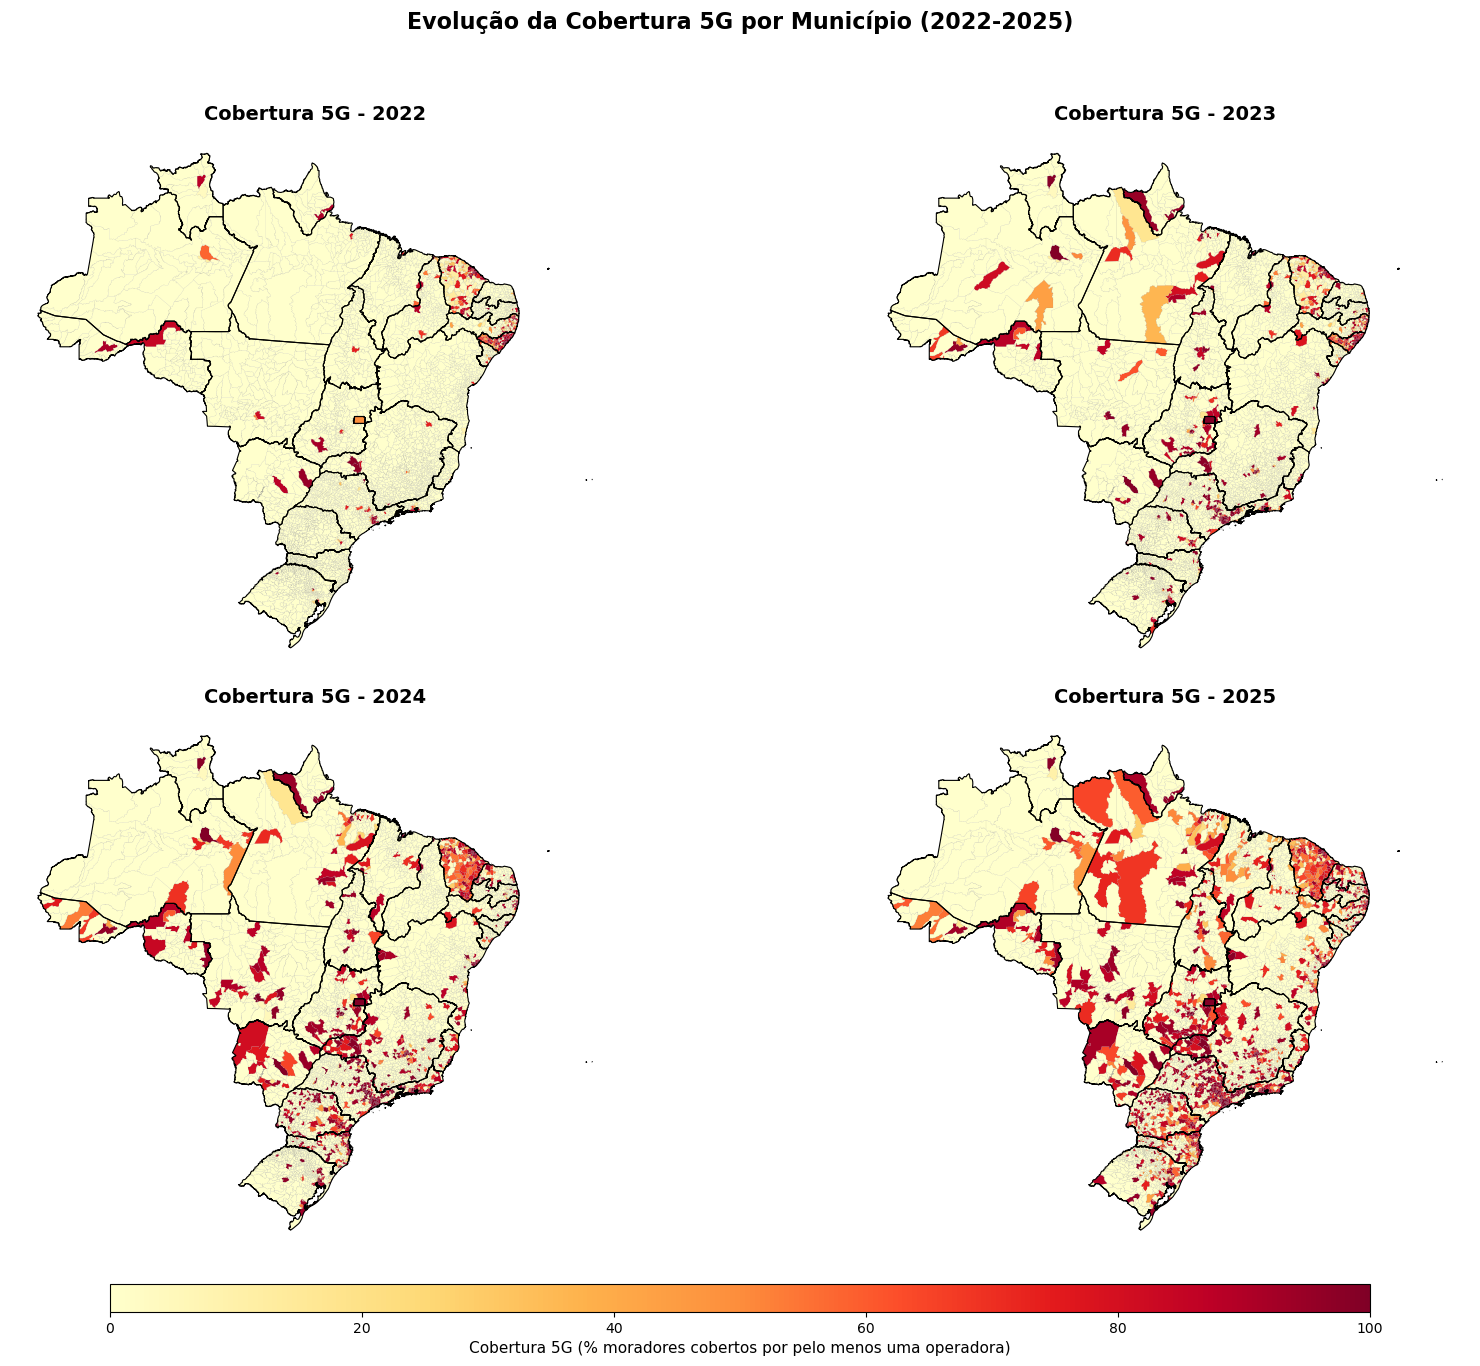

In [14]:
# =========================================================
# MAPA COROPLÉTICO: Cobertura 5G por município (2022-2025)
# Inclui contorno dos estados
# =========================================================
import pandas as pd
import geopandas as gpd
import geobr
import matplotlib.pyplot as plt
import os

# 1. Carregar dados da base unificada de municípios
caminho_muni = os.path.abspath("output/base_unificada_municipios.csv.gz")
cols = ['Código Município', 'UF', 'Tecnologia', 'Período', '% moradores cobertos']
df = pd.read_csv(caminho_muni, sep=';', compression='gzip', usecols=cols, low_memory=False)

# Converter cobertura para numérico
df['% moradores cobertos'] = (df['% moradores cobertos']
                              .astype(str)
                              .str.replace(',', '.', regex=False)
                              .pipe(pd.to_numeric, errors='coerce')
                              .fillna(0.0))

# Escala: se máximo <= 1, converter para percentual
if df['% moradores cobertos'].max() <= 1.0:
    df['% moradores cobertos'] *= 100

# Filtrar 5G
df_5g = df[df['Tecnologia'] == '5G'].copy()
df_5g['Período'] = pd.to_datetime(df_5g['Período'])
df_5g['Ano'] = df_5g['Período'].dt.year

# 2. Calcular para cada município e ano a cobertura máxima entre operadoras
cobertura_muni = df_5g.groupby(['Código Município', 'Ano'])['% moradores cobertos'].max().reset_index()
cobertura_muni.rename(columns={'% moradores cobertos': 'cobertura_max'}, inplace=True)

# 3. Obter geometria dos municípios (IBGE 2020)
print("Baixando geometria dos municípios...")
municipios_geo = geobr.read_municipality(year=2020)
municipios_geo['code_muni'] = municipios_geo['code_muni'].astype(int)

# 4. Obter geometria dos estados para contorno
estados_geo = geobr.read_state(year=2020)

# 5. Definir anos desejados (2022 a 2025)
anos = [2022, 2023, 2024, 2025]
# Filtrar apenas os anos que existem nos dados
anos_existentes = [a for a in anos if a in cobertura_muni['Ano'].unique()]
if not anos_existentes:
    raise ValueError("Nenhum dado encontrado para os anos 2022-2025.")

# 6. Criar subplots 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Escala comum (0 a 100)
vmin, vmax = 0, 100

for i, ano in enumerate(anos_existentes):
    ax = axes[i]
    
    # Dados do ano
    dados_ano = cobertura_muni[cobertura_muni['Ano'] == ano].copy()
    # Merge com geometria
    mapa = municipios_geo.merge(dados_ano, left_on='code_muni', right_on='Código Município', how='left')
    # Preencher NaN com 0 (municípios sem dado ou sem cobertura)
    mapa['cobertura_max'] = mapa['cobertura_max'].fillna(0)
    
    # Plotar municípios (coropletico)
    mapa.plot(column='cobertura_max', cmap='YlOrRd', linewidth=0.05, edgecolor='gray',
              vmin=vmin, vmax=vmax, legend=False, ax=ax)
    
    # Plotar contorno dos estados (linha preta fina)
    estados_geo.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8, facecolor='none')
    
    ax.set_title(f'Cobertura 5G - {ano}', fontsize=14, fontweight='bold')
    ax.set_axis_off()

# Remover subplots não utilizados (caso menos de 4 anos)
for j in range(len(anos_existentes), len(axes)):
    axes[j].set_axis_off()

# Adicionar legenda comum (horizontal)
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])
sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Cobertura 5G (% moradores cobertos por pelo menos uma operadora)', fontsize=11)

fig.suptitle('Evolução da Cobertura 5G por Município (2022-2025)', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

### 4.1 Análise do Mapa Coroplético: O Efeito Mancha de Óleo

#### 4.1.1 O que os Mapas Revelam

Os mapas coropléticos da cobertura 5G por município (2022–2025) documentam visualmente um dos padrões mais clássicos de difusão de infraestrutura em países continentais: o **efeito mancha de óleo** (*oil spill effect*).

O fenômeno parte dos **grandes centros urbanos** com alta densidade populacional e poder aquisitivo concentrado, onde o retorno sobre o investimento das operadoras é imediato. A partir desses núcleos, a cobertura se expande gradualmente para os municípios do entorno, alcançando primeiro as cidades médias da região metropolitana, depois os polos regionais e, por último, os municípios menores e mais distantes. Como uma mancha de óleo que se alastra em papel, o movimento não ocorre de forma homogênea: avança mais rápido onde há densidade e retrocede onde há dispersão.

#### 4.1.2 Leitura Ano a Ano

Em 2022, o mapa registra manchas pequenas e isoladas, concentradas majoritariamente nas capitais do Sudeste e em alguns estados do Nordeste. O interior do país permanece inteiramente sem cobertura. Um destaque já neste ano inicial é o **Ceará**, que apresenta níveis de cobertura superiores à média nacional para o período, reflexo da atuação de um player regional com estratégia de expansão mais agressiva no estado, demonstrando que a presença de competidores locais pode acelerar a chegada do 5G a regiões que o mercado nacional tenderia a postergar.

Em 2023, as manchas crescem a partir dos seus núcleos originais. O Distrito Federal já apresenta cobertura muito intensa, e estados como Ceará e Pernambuco mostram expansões que começam a ultrapassar as fronteiras das capitais. As manchas crescem, mas ainda de forma fragmentada.

Em 2024, a expansão radial a partir dos grandes centros torna-se visível. São Paulo, Rio de Janeiro e suas regiões metropolitanas mostram espraiamento para municípios vizinhos. No Nordeste, Fortaleza e Recife ganham profundidade territorial. No Sul, Curitiba e Porto Alegre avançam sobre suas periferias.

Em 2025, o mapa evidencia o início da fusão entre manchas antes separadas. O corredor Sudeste começa a se conectar, e o interior de estados como Ceará e Rio Grande do Norte apresenta cobertura mais contínua. O padrão de mancha de óleo se consolida: onde havia pontos isolados, surgem regiões contínuas de conectividade.

#### 4.1.3 Disparidades Regionais Persistentes

Apesar da progressão, o mapa de 2025 ainda evidencia disparidades estruturais profundas entre as regiões brasileiras. O Centro-Oeste apresenta o Distrito Federal praticamente saturado, enquanto os estados vizinhos ainda estão em expansão inicial, reflexo da concentração de demanda institucional e corporativa na capital federal. No Sudeste, São Paulo e Rio de Janeiro concentram a maior extensão territorial coberta, impulsionados pela combinação de alta densidade urbana, infraestrutura de fibra óptica já consolidada e forte demanda empresarial por conectividade de alta velocidade. O Nordeste exibe um padrão dual: o litoral e as capitais avançam bem, enquanto o sertão permanece quase inteiramente descoberto, resultado da baixa densidade demográfica e da renda per capita reduzida que inibe o investimento privado espontâneo. A exceção permanece sendo o Ceará, cujo interior apresenta cobertura relativamente superior aos demais estados da região, evidenciando novamente o papel do player regional como indutor de expansão. No Norte, a cobertura se restringe a pontos isolados nas capitais, onde os desafios logísticos de implantação em território de floresta e a dispersão populacional tornam o custo por usuário atendido proibitivo para o modelo de negócios convencional. O Sul avança de forma mais equilibrada, beneficiado pela malha urbana relativamente densa e distribuída entre municípios de porte médio, o que reduz o custo marginal de expansão da rede.

#### 4.1.4 Relação com o ODS 9

O padrão de mancha de óleo é, em si, uma evidência do desafio que o **ODS 9, Meta 9.c** coloca: aumentar significativamente o acesso às tecnologias de informação e comunicação e oferecer acesso universal e a preços acessíveis à internet.

A expansão concentrada em áreas de alta densidade e alto poder aquisitivo é racionalmente explicada pelo modelo de negócios das operadoras privadas, que priorizam mercados com maior retorno sobre o investimento. Contudo, essa lógica produz exatamente o padrão que o ODS busca reverter: quem mais precisa de conectividade para superar desigualdades estruturais é quem menos acessa a tecnologia mais avançada disponível.

A velocidade de chegada da mancha ao interior do Brasil será, portanto, um dos termômetros mais concretos de progresso em direção à meta do ODS 9 até 2030.

Anos disponíveis: [2022, 2023, 2024, 2025]


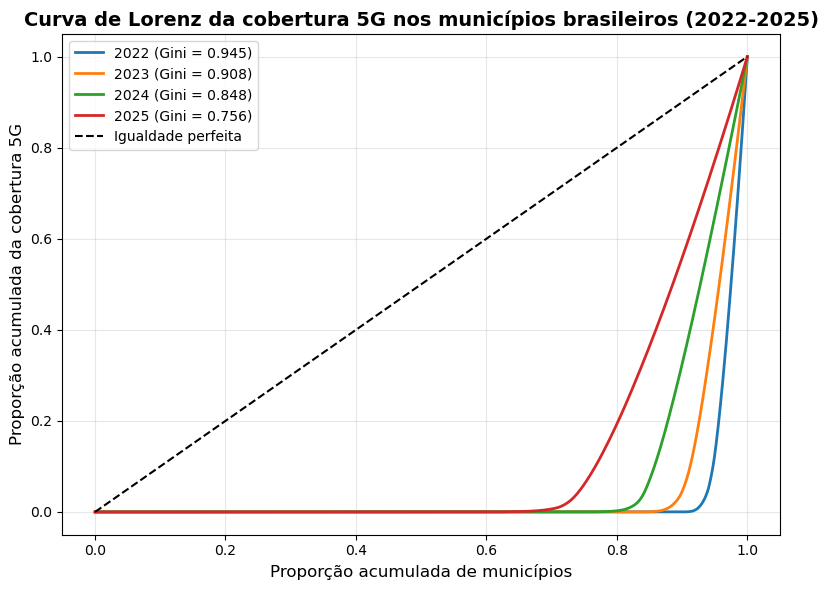

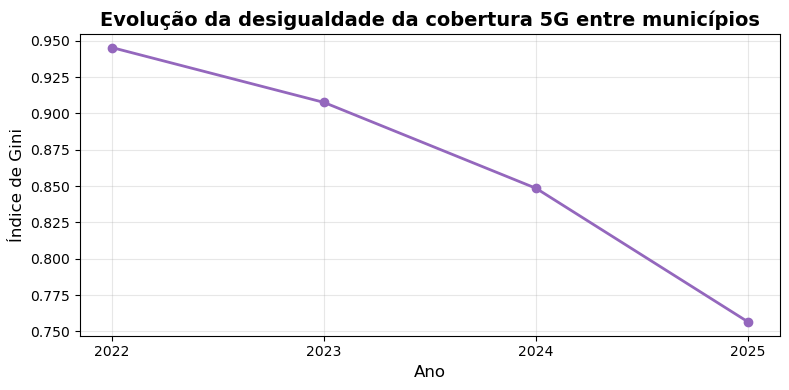


Índice de Gini por ano:
2022: 0.9453
2023: 0.9076
2024: 0.8485
2025: 0.7565


In [ ]:
# =========================================================
# CURVA DE LORENZ EVOLUTIVA (2022-2025)
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Carregar dados
caminho_muni = os.path.abspath("output/base_unificada_municipios.csv.gz")
cols = ['Código Município', 'Tecnologia', 'Período', '% moradores cobertos']
df = pd.read_csv(caminho_muni, sep=';', compression='gzip', usecols=cols, low_memory=False)

# Converter cobertura
df['% moradores cobertos'] = (df['% moradores cobertos']
                              .astype(str)
                              .str.replace(',', '.', regex=False)
                              .pipe(pd.to_numeric, errors='coerce')
                              .fillna(0.0))
if df['% moradores cobertos'].max() <= 1.0:
    df['% moradores cobertos'] *= 100

# Filtrar 5G
df_5g = df[df['Tecnologia'] == '5G'].copy()
df_5g['Período'] = pd.to_datetime(df_5g['Período'])
df_5g['Ano'] = df_5g['Período'].dt.year

# Anos de interesse (2022-2025, apenas os que existem)
anos_desejados = [2022, 2023, 2024, 2025]
anos_existentes = [ano for ano in anos_desejados if ano in df_5g['Ano'].unique()]
print(f"Anos disponíveis: {anos_existentes}")

# Cores para cada ano
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Preparar figura (tamanho original)
plt.figure(figsize=(8, 6))
gini_por_ano = []

for i, ano in enumerate(anos_existentes):
    cobertura_ano = df_5g[df_5g['Ano'] == ano].groupby('Código Município')['% moradores cobertos'].max()
    cobertura_sorted = cobertura_ano.sort_values().values
    n = len(cobertura_sorted)
    p = np.arange(1, n+1) / n
    L = np.cumsum(cobertura_sorted) / np.sum(cobertura_sorted)
    area = np.trapz(L, p)
    gini = 1 - 2 * area
    gini_por_ano.append((ano, gini))
    plt.plot(p, L, linewidth=2, color=cores[i], label=f'{ano} (Gini = {gini:.3f})')

# Linha de igualdade
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Igualdade perfeita')

# Legendas
plt.xlabel('Proporção acumulada de municípios', fontsize=12)
plt.ylabel('Proporção acumulada da cobertura 5G', fontsize=12)
plt.title('Curva de Lorenz da cobertura 5G nos municípios brasileiros (2022-2025)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Legenda no canto superior esquerdo (dentro do gráfico)
plt.legend(loc='upper left', frameon=True, fancybox=True, shadow=False)

plt.tight_layout()
plt.show()

# Gráfico da evolução do Gini (mantido)
df_gini = pd.DataFrame(gini_por_ano, columns=['Ano', 'Gini'])
plt.figure(figsize=(8, 4))
plt.plot(df_gini['Ano'], df_gini['Gini'], marker='o', linewidth=2, color='#9467bd')
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Índice de Gini', fontsize=12)
plt.title('Evolução da desigualdade da cobertura 5G entre municípios', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(df_gini['Ano'])
plt.tight_layout()
plt.show()

# Exibir valores
print("\nÍndice de Gini por ano:")
for ano, gini in gini_por_ano:
    print(f"{ano}: {gini:.4f}")

### 4.2 Análise da Curva de Lorenz e do Índice de Gini: Desconcentração em Marcha

#### 4.2.1 Leitura da Curva de Lorenz

A Curva de Lorenz é uma ferramenta originalmente criada para medir desigualdade de renda, aqui adaptada para mensurar a **concentração da cobertura 5G entre os municípios brasileiros**. Quanto mais a curva se afasta da diagonal de igualdade perfeita, mais concentrada é a distribuição.

Os resultados são contundentes:

- **2022 (Gini = 0,945):** Em 2022, aproximadamente **85% dos municípios** acumulavam menos de 5% da cobertura 5G total do país. A quase totalidade do sinal estava concentrada em menos de 15% das cidades. Uma concentração de nível extremo.

- **2023 (Gini = 0,908):** A curva começa a se deslocar em direção à diagonal, mas o nível ainda é altíssimo. O 5G permanece um privilégio de poucos centros urbanos.

- **2024 (Gini = 0,848):** A queda de 0,06 pontos em relação a 2023 representa a maior redução do período, coincidindo com a fase de maior expansão das manchas observadas nos mapas. O sinal começa a chegar a municípios médios.

- **2025 (Gini = 0,756):** A curva de 2025 é visivelmente mais próxima da diagonal que a de 2022: a proporção de municípios com zero cobertura começa a se contrair. A queda acumulada de **0,189 pontos em 3 anos** é expressiva em termos absolutos, mas o Gini de 0,756 ainda é **50% superior ao Gini de renda do Brasil** (≈ 0,52 pelo IBGE), o que ilustra que a desigualdade de conectividade é estruturalmente mais severa do que a desigualdade de renda.

#### 4.2.2 O Que o Gini Não Captura

O Índice de Gini é um número único que resume uma distribuição inteira e, como qualquer resumo, perde informação. Neste contexto, é importante destacar:

- **O Gini mede concentração relativa, não cobertura absoluta:** Um Gini de 0,756 em 2025 ainda é compatível com a maioria dos municípios tendo cobertura zero ou próxima de zero. A desconcentração observada é real, mas ainda está longe de uma distribuição equitativa.
- **O ritmo importa:** A trajetória de queda (0,945 → 0,908 → 0,848 → 0,756) sugere uma aceleração da desconcentração. Se essa aceleração se mantiver, o Gini pode atingir níveis abaixo de 0,6 até 2028, um patamar ainda alto, mas que indicaria um salto qualitativo na democratização do acesso.

#### 4.2.3 Conexão com o ODS 9, Meta 9.c

A trajetória descendente do Gini é uma das evidências mais objetivas de progresso em direção ao **ODS 9**, mas deve ser contextualizada:

> *A redução da desigualdade de cobertura é condição necessária, mas não suficiente, para o alcance da meta de conectividade universal.*

Para que o ODS 9 seja cumprido até 2030, não basta que a distribuição de cobertura entre municípios se torne mais equitativa: é preciso que o **nível absoluto de cobertura** alcance patamares que garantam acesso real à população. Os cenários de projeção (Seção 3) indicam que, mantida a inércia atual, a cobertura média nacional permanecerá em níveis de um dígito percentual até 2028.

Isso aponta para uma **janela de intervenção política crítica**: a trajetória espontânea do mercado reduzirá o Gini, mas não na velocidade nem na abrangência necessárias para cumprir os compromissos do ODS 9 até o prazo estabelecido. Políticas públicas de universalização como obrigações de cobertura em editais de radiofrequência, subsídios para municípios de baixo ROI e expansão da infraestrutura de backhaul em regiões remotas são instrumentos indispensáveis para complementar o movimento espontâneo do mercado.